# 00 · Exploratory Data Analysis

## The F₂ Proton Structure Function

The electromagnetic proton structure function $F_2^p(x, Q^2)$ is measured in
**Deep Inelastic Scattering (DIS)** experiments.

* **x** – Bjorken scaling variable: fraction of the proton momentum carried by the struck quark
* **Q²** – virtuality (resolution scale) of the exchanged photon [GeV²]

At small x the gluon sea drives a steep rise in F₂ (Pomeron/BFKL dynamics).
This project applies a suite of ML methods to model and extrapolate F₂ into the
low-x region where data are sparse.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["figure.dpi"] = 120

from data_loader import load_lepton_dis, add_log_features, split_data, get_Xy, low_x_grid
from visualization import plot_coverage, plot_F2_vs_x, comparison_figure

DATA_DIR = "/Users/dikgarg/Desktop/Research/Neutrinos/postdoc/2025/ML/Data/Exp_data/LeptonDIS"

df_raw = load_lepton_dis(DATA_DIR)
df     = add_log_features(df_raw)
df_train, df_test = split_data(df, test_size=0.2, seed=42)

X_train, y_train = get_Xy(df_train)
X_test,  y_test  = get_Xy(df_test)

print(f"Training points: {len(X_train)}  |  Test points: {len(X_test)}")


Loaded 7 experiment files → 1472 data points
  BCDMS-F2p_RQCD-q0.dat
  H1-F2p-q0.dat
  NMC92-F2p280-q0.dat
  NMC92-F2p90-q0.dat
  NMC97-F2p-q0.dat
  SLAC-F2p-q0.dat
  ZEUS-F2p-q0.dat
Training points: 1177  |  Test points: 295


## Dataset Summary

In [2]:
summary = (
    df.groupby("experiment")
    .agg(
        n_points=("F2", "count"),
        x_min=("x", "min"),
        x_max=("x", "max"),
        Q2_min=("Q2", "min"),
        Q2_max=("Q2", "max"),
        F2_mean=("F2", "mean"),
    )
    .round(4)
)
print(summary.to_string())


            n_points   x_min   x_max  Q2_min    Q2_max  F2_mean
experiment                                                     
BCDMS            488  0.0700  0.7500   7.500   230.000   0.2039
H1                21  0.0002  0.0133   8.500    60.000   1.1305
NMC92            127  0.0080  0.5000   0.800    46.860   0.3429
NMC97            158  0.0045  0.5000   0.750    65.000   0.3372
SLAC             661  0.0630  0.9000   0.581    30.314   0.1934
ZEUS              17  0.0004  0.0320  15.000  1000.000   1.0053


## Data Coverage in the $(x, Q^2)$ Plane

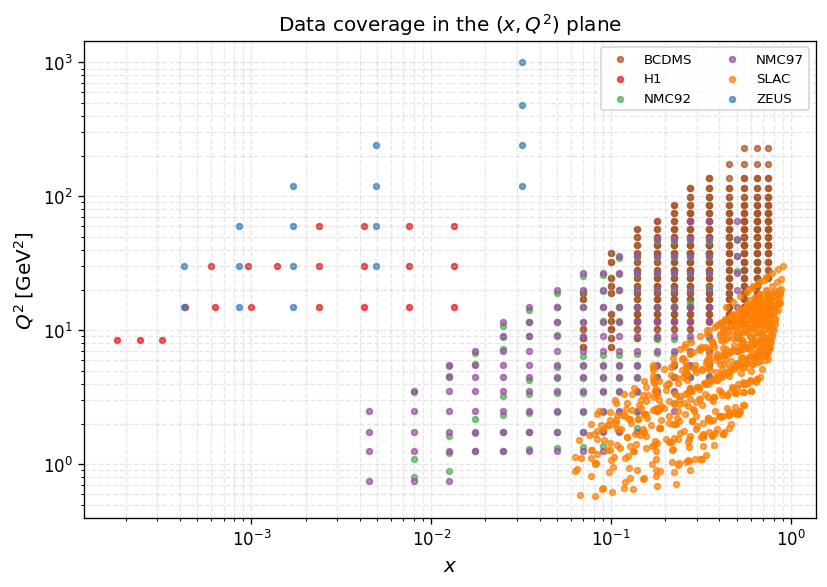

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_coverage(df, ax=ax)
plt.tight_layout()
#plt.savefig("../results/figures/00_coverage.png", dpi=150)
plt.show()


## Distribution of $F_2^p$ Values

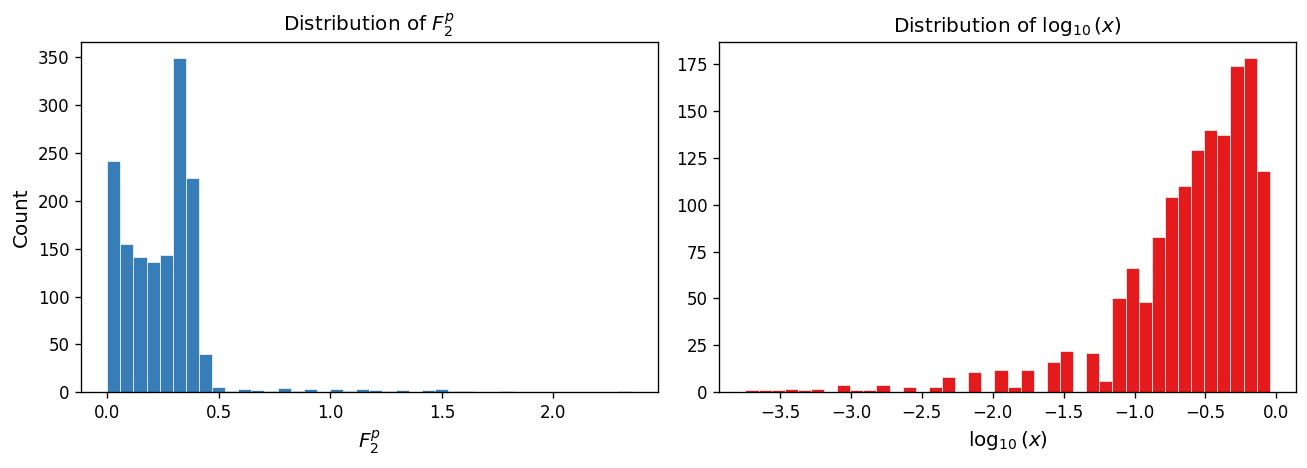

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df["F2"], bins=40, color="#377eb8", edgecolor="white", linewidth=0.4)
axes[0].set_xlabel(r"$F_2^p$", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].set_title("Distribution of $F_2^p$", fontsize=12)

axes[1].hist(df["log10_x"], bins=40, color="#e41a1c", edgecolor="white", linewidth=0.4)
axes[1].set_xlabel(r"$\log_{10}(x)$", fontsize=12)
axes[1].set_title(r"Distribution of $\log_{10}(x)$", fontsize=12)

plt.tight_layout()
#plt.savefig("../results/figures/00_distributions.png", dpi=150)
plt.show()


## $F_2^p$ vs $x$ at Fixed $Q^2$ Bins

/Users/dikgarg/Desktop/proton_structure_ml/notebooks/../src/visualization.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7, ncol=2)


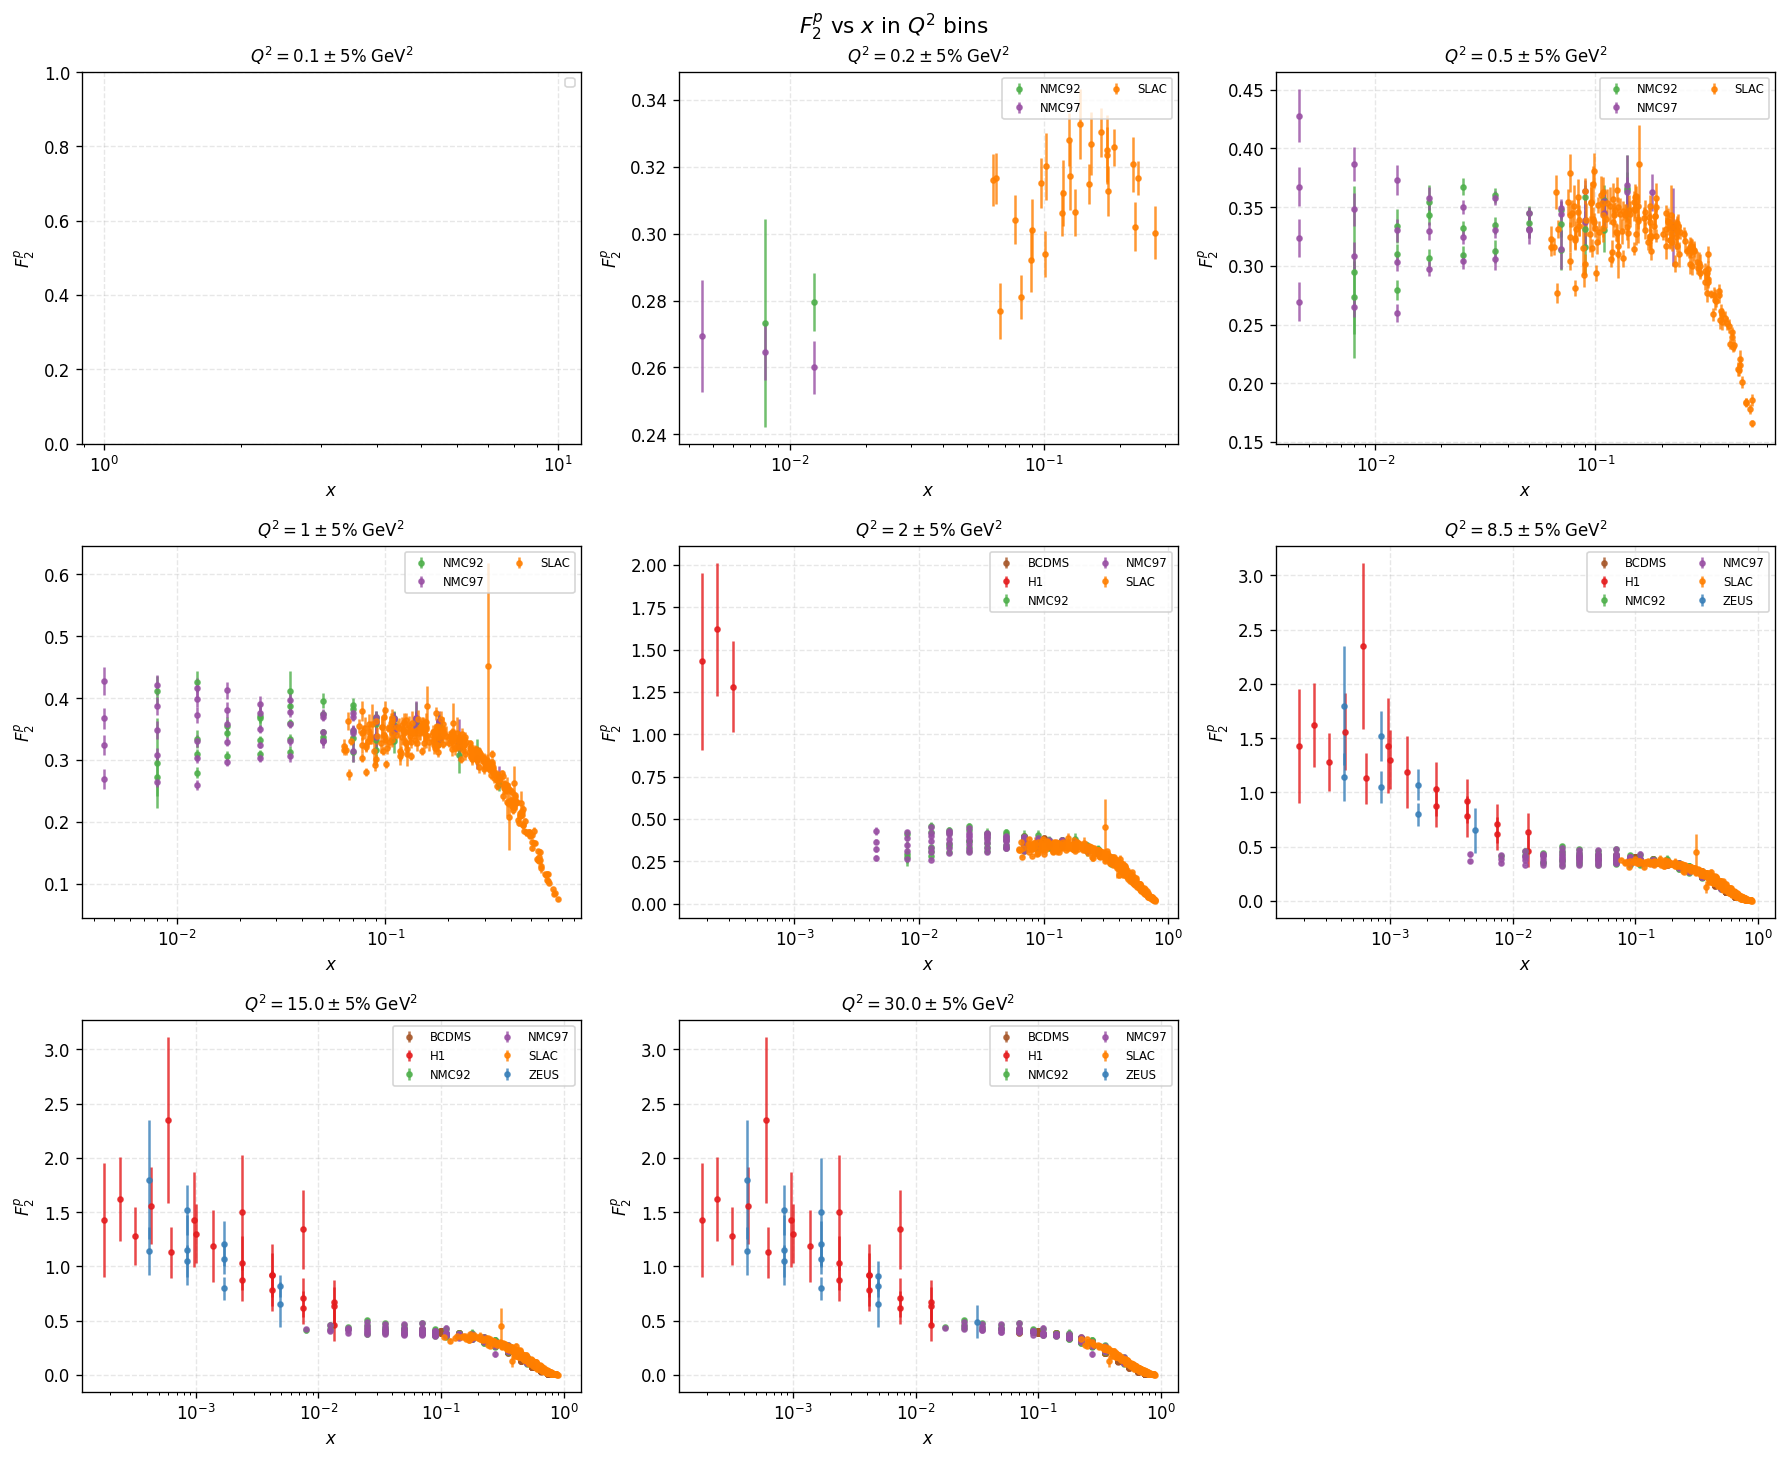

In [ ]:
Q2_vals = [0.1, 0.2, .5, 1, 2, 8.5, 15.0, 30.0] #, 60.0, 120.0]
fig, axes = plot_F2_vs_x(df, Q2_vals, delta=5, ncols=3) #tolerance bins are not done correctly (i.e. delta)!!!! FIX
fig.suptitle(r"$F_2^p$ vs $x$ in $Q^2$ bins", fontsize=13, y=1.01)
#plt.savefig("../results/figures/00_F2_vs_x.png", dpi=150, bbox_inches="tight")
plt.show()


## $F_2^p$ vs $Q^2$ at Fixed $x$ Bins

/Users/dikgarg/anaconda3/envs/ML/lib/python3.10/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


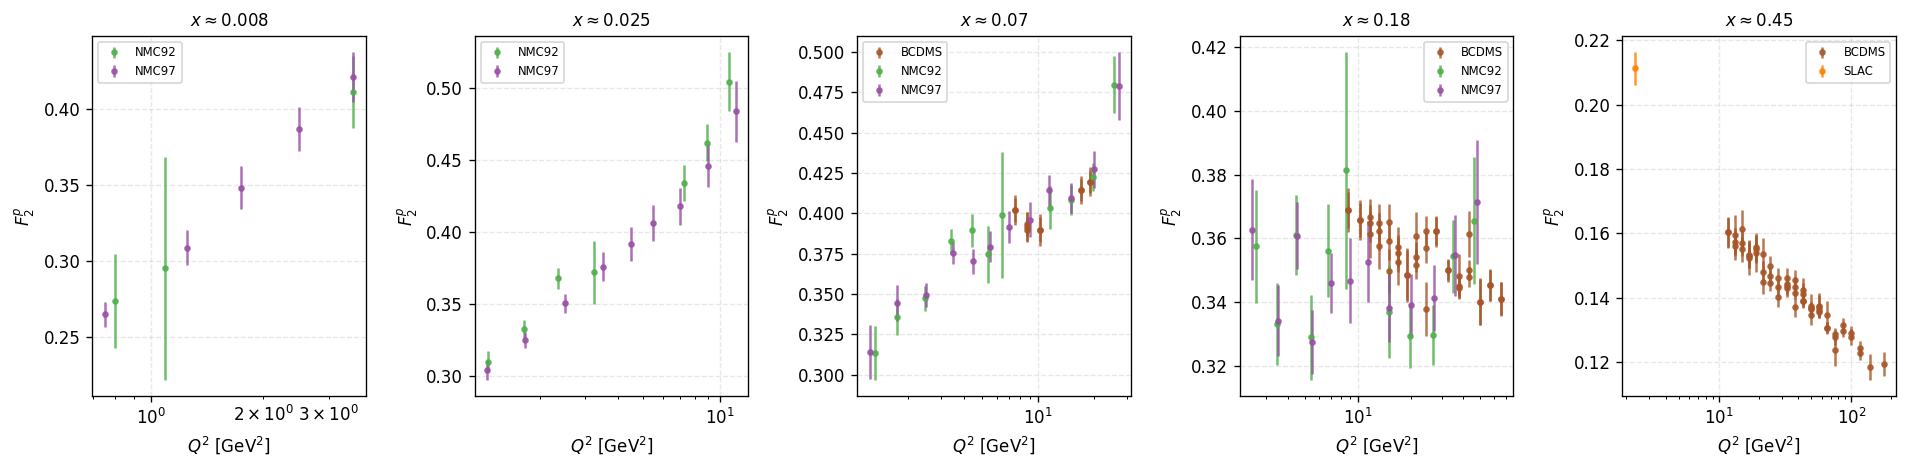

In [27]:
from visualization import EXP_COLORS

x_centres = [0.008, 0.025, 0.07, 0.18, 0.45]

fig, axes = plt.subplots(1, len(x_centres), figsize=(16, 4), sharey=False)
for ax, xc in zip(axes, x_centres):
    sub = df[df["x"] == xc]
    for exp, grp in sub.groupby("experiment"):
        ax.errorbar(grp["Q2"], grp["F2"],
                    yerr=[grp["sigma_dn"], grp["sigma_up"]],
                    fmt="o", ms=3, alpha=0.8,
                    color=EXP_COLORS.get(exp, "grey"), label=exp)
    ax.set_xscale("log")
    ax.set_xlabel(r"$Q^2$ [GeV$^2$]", fontsize=10)
    ax.set_ylabel(r"$F_2^p$", fontsize=10)
    ax.set_title(rf"$x \approx {xc}$", fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(True, ls="--", alpha=0.3)

plt.tight_layout()
#plt.savefig("../results/figures/00_F2_vs_Q2.png", dpi=150)
plt.show()


## Feature Correlation Matrix

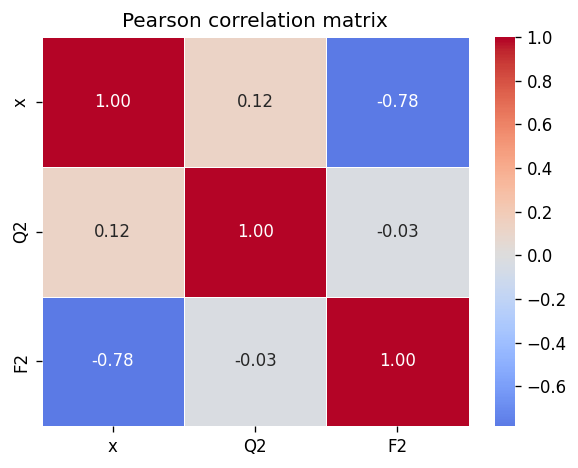

In [9]:
import seaborn as sns

feat_df = df[["x", "Q2", "F2"]].copy()
feat_df.columns = ["x", "Q2", "F2"]

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(feat_df.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, linewidths=0.5)
ax.set_title("Pearson correlation matrix", fontsize=12)
plt.tight_layout()
#plt.savefig("../results/figures/00_correlation.png", dpi=150)
plt.show()


## Key Observations

1. **Wide kinematic range**: x spans ~4 orders of magnitude; Q² spans ~3 orders.
2. **Rise at low x**: F₂ increases as x decreases, especially visible in the HERA data (H1, ZEUS).
3. **Strong log-log linearity** between x and Q²: log₁₀(x) and log₁₀(Q²) are the natural input features.
4. **Low-x gap**: measurements stop around x ~ 10⁻⁴; this is the region we want to extrapolate into.
